# SQL Exploration — Part I

This notebook is the trial-and-error workspace (see `CONVENTIONS.md`). It:
1. Sets up the 4 hypothetical tables from the prompt in DuckDB with synthetic data.
2. Builds each query piece by piece, showing how the result changes at each step.

The final, clean version of each query (without the intermediate steps) is later copied to `sql/sql_queries.sql`.

## Contents

- **Step 0:** synthetic data setup for the 4 hypothetical tables, with seeded edge cases used to validate every query.
- **Questions 1-5:** each query is built up incrementally (a simple version first, then filters, joins, and window functions added step by step) before being finalized in `sql/sql_queries.sql`.
- **Questions 3 and 5:** the data-driven minimum-deliveries threshold shared by both questions, computed with window functions. Question 3's prompt specifies a fixed cutoff (couriers with at least 50 deliveries); this was replaced with a data-driven threshold instead, so the same rule adapts to whatever data size is actually available if applied to a new dataset. On this dataset, the change does not alter the outcome for Question 3 — the stricter, data-driven threshold produces the exact same top-10 result the fixed `>= 50` cutoff would have (full comparison: `sql/sql_insights.md`).

Findings and methodology notes are consolidated in `sql/sql_insights.md`.

## 0. Synthetic data setup

[DuckDB](https://duckdb.org/) is used because it is a SQL engine that runs embedded in Python (no separate database server to install), and it integrates well with `pandas`: the data can be generated into a DataFrame and then inserted directly into a real SQL table.

`np.random.seed(42)` fixes the random number generator's "seed": this way, every time this notebook is run, the **same** synthetic data is generated (reproducibility), instead of different numbers each time.

In [1]:
import duckdb
import numpy as np
import pandas as pd

np.random.seed(42)
con = duckdb.connect(database=":memory:")  # in-memory database, scoped to this session

### The 4 tables, with the exact schema from the prompt

`CREATE TABLE` defines each column's name and data type (`VARCHAR` = text, `INT` = integer, `FLOAT` = decimal, `TIMESTAMP` = date+time, `DATE` = date only, `BOOLEAN` = true/false). There are no rows yet, just the empty structure.

**Detail worth flagging for later:** `deliveries.delivery_person_id` is `VARCHAR`, but `delivery_persons.delivery_person_id` is `INT`. This is a real inconsistency in the prompt (not an error introduced here) — later, when joining these two tables, one of the two types will need a `CAST` so they match. For now, Question 1 does not need it, since it involves no join.

In [2]:
con.execute("""
CREATE TABLE deliveries (
    delivery_id VARCHAR,
    delivery_person_id VARCHAR,
    restaurant_area VARCHAR,
    customer_area VARCHAR,
    delivery_distance_km FLOAT,
    delivery_time_min INT,
    order_placed_at TIMESTAMP,
    weather_condition VARCHAR,
    traffic_condition VARCHAR,
    delivery_rating FLOAT
)
""")

con.execute("""
CREATE TABLE delivery_persons (
    delivery_person_id INT,
    name VARCHAR,
    region VARCHAR,
    hired_date DATE,
    is_active BOOLEAN
)
""")

con.execute("""
CREATE TABLE restaurants (
    restaurant_id VARCHAR,
    area VARCHAR,
    name VARCHAR,
    cuisine_type VARCHAR,
    avg_preparation_time_min FLOAT
)
""")

con.execute("""
CREATE TABLE orders (
    order_id INT,
    delivery_id VARCHAR,
    restaurant_id VARCHAR,
    customer_id VARCHAR,
    order_value FLOAT,
    items_count INT
)
""")

print("4 tables created (empty)")

4 tables created (empty)


### Why the synthetic data was generated this way

**180 days** of deliveries are generated (counting back from today), with ~14 deliveries/day on average, spread across 10 customer areas, 15 couriers, and 20 restaurants. `pd.Timestamp.now()` is used as the reference date (not a fixed date) so that, no matter when this notebook is re-run, "the last 30 days" in the queries always lines up with genuinely recent data in the synthetic dataset.

Edge cases seeded on purpose, with the 5 questions in mind:

- **Question 1** (top areas, last 30 days): the **Riverside** area has a normal delivery time for most of the period, but gets +20 min added *only in the last 30 days* (e.g. recent roadworks). **Old Town** is the opposite: it had a serious problem (+25 min) that has since been resolved, so it only shows up in data *older* than the last 30 days. This is used to confirm that the date filter genuinely changes the ranking — if the date `WHERE` were forgotten, Old Town would appear as the worst area, even though it is no longer a current problem.
- **Question 3** (fastest couriers, 50+ deliveries, active): courier `3` is fast, active, and has ~500+ deliveries. Courier `5` is just as fast but **inactive** — this confirms that the `is_active` filter actually excludes them (without it, they would appear as the fastest). Couriers `14` and `15` are "recently hired" with very few deliveries (<50), confirming that the volume filter also excludes them.
- **Question 5** (increasing trend): courier `7` has an effect that makes their delivery time grow month over month (from ~48 to ~60 min), simulating something gradually getting worse (e.g. a route that deteriorated, fatigue, etc.), while the rest of the couriers stay relatively stable.

Questions 2 and 4 did not need special biases: reasonable variety in weather/traffic/cuisine/order value is enough to answer them with data that makes business sense.

In [3]:
today = pd.Timestamp.now().normalize()
n_days = 180
start_date = today - pd.Timedelta(days=n_days)

areas = ["Downtown", "Uptown", "Riverside", "Midtown", "Eastside",
         "Westside", "Old Town", "Suburbia", "Lakeside", "Hillcrest"]
cuisines = ["Italian", "Fast Food", "Sushi", "Indian", "Mexican", "Vegan", "Pizza", "Chinese"]

# each area's own "base" delivery time (e.g. farther or more congested areas)
area_base_time = {a: np.random.uniform(25, 40) for a in areas}

def area_special_effect(area, order_date):
    """Riverside: recent problem (<=30 days). Old Town: already-resolved problem (>30 days)."""
    days_ago = (today - order_date).days
    effect = 0.0
    if area == "Riverside" and days_ago <= 30:
        effect += 20.0
    if area == "Old Town" and days_ago > 30:
        effect += 25.0
    return effect

courier_ids = list(range(1, 16))
inactive_ids = {5, 12}       # couriers no longer working on the platform
new_hire_ids = {14, 15}      # recently hired, still with few deliveries
fast_ids = {3, 5}            # genuinely fast couriers (one active, one inactive)
trend_courier = 7            # courier with an increasing delivery-time trend

weights = []
for cid in courier_ids:
    if cid in fast_ids:
        weights.append(4.0)   # more volume, to guarantee 50+ deliveries
    elif cid in new_hire_ids:
        weights.append(0.05)  # very little volume, to stay under 50 deliveries
    else:
        weights.append(1.0)
weights = np.array(weights)
weights /= weights.sum()

print("Courier setup ready")

Courier setup ready


In [4]:
records = []
delivery_counter = 1

for day_offset in range(n_days):
    order_date = start_date + pd.Timedelta(days=day_offset)
    days_ago = (today - order_date).days
    n_today = np.random.poisson(14)

    for _ in range(n_today):
        courier_id = int(np.random.choice(courier_ids, p=weights))
        area = np.random.choice(areas)
        restaurant_area = np.random.choice(areas)
        distance = round(float(np.random.uniform(1, 15)), 2)
        weather = np.random.choice(["Clear", "Rainy", "Cloudy", "Stormy"], p=[0.55, 0.2, 0.2, 0.05])
        traffic = np.random.choice(["Low", "Medium", "High"], p=[0.4, 0.4, 0.2])

        base_time = 20 + distance * 1.5
        weather_effect = {"Clear": 0, "Cloudy": 2, "Rainy": 8, "Stormy": 15}[weather]
        traffic_effect = {"Low": 0, "Medium": 6, "High": 14}[traffic]
        area_effect = area_base_time[area] - 30
        special_effect = area_special_effect(area, order_date)
        courier_effect = -8.0 if courier_id in fast_ids else 0.0
        trend_effect = ((n_days - days_ago) / n_days) * 20 if courier_id == trend_courier else 0.0
        noise = np.random.normal(0, 4)

        delivery_time = (base_time + weather_effect + traffic_effect + area_effect
                          + special_effect + courier_effect + trend_effect + noise)
        delivery_time = int(np.clip(delivery_time, 10, 120))

        order_time = order_date + pd.Timedelta(hours=float(np.random.uniform(8, 22)))
        rating = round(float(np.clip(np.random.normal(4.3, 0.5), 1, 5)), 1)

        records.append({
            "delivery_id": f"D{delivery_counter:06d}",
            "delivery_person_id": str(courier_id),  # VARCHAR, matching the deliveries table schema
            "restaurant_area": restaurant_area,
            "customer_area": area,
            "delivery_distance_km": distance,
            "delivery_time_min": delivery_time,
            "order_placed_at": order_time,
            "weather_condition": weather,
            "traffic_condition": traffic,
            "delivery_rating": rating,
        })
        delivery_counter += 1

deliveries_df = pd.DataFrame(records)
print(f"{len(deliveries_df)} deliveries generated")
deliveries_df.head()

2550 deliveries generated


,delivery_id,delivery_person_id,restaurant_area,customer_area,delivery_distance_km,delivery_time_min,order_placed_at,weather_condition,traffic_condition,delivery_rating
0,D000001,3,Downtown,Eastside,5.26,26,2026-02-12 09:57:10.490576862,Clear,Medium,3.5
1,D000002,3,Old Town,Riverside,14.77,52,2026-02-12 08:11:08.554042457,Clear,High,5.0
2,D000003,12,Hillcrest,Uptown,5.26,39,2026-02-12 14:55:56.916269608,Clear,Medium,4.2
3,D000004,1,Midtown,Downtown,3.55,35,2026-02-12 08:26:18.189939760,Cloudy,Medium,3.6
4,D000005,11,Hillcrest,Uptown,13.53,71,2026-02-12 13:26:29.335400349,Rainy,High,4.1


In [5]:
# delivery_persons
regions = ["North", "South", "East", "West"]
dp_records = []
for cid in courier_ids:
    if cid in new_hire_ids:
        hired = today - pd.Timedelta(days=int(np.random.uniform(5, 20)))
    else:
        hired = today - pd.Timedelta(days=int(np.random.uniform(60, 1000)))
    dp_records.append({
        "delivery_person_id": cid,
        "name": f"Courier_{cid:02d}",
        "region": np.random.choice(regions),
        "hired_date": hired.date(),
        "is_active": cid not in inactive_ids,
    })
delivery_persons_df = pd.DataFrame(dp_records)

# restaurants: 2 per area, for area/cuisine variety
r_records = []
rid = 1
for area in areas:
    for _ in range(2):
        r_records.append({
            "restaurant_id": f"R{rid:03d}",
            "area": area,
            "name": f"Restaurant_{rid:03d}",
            "cuisine_type": np.random.choice(cuisines),
            "avg_preparation_time_min": round(float(np.random.uniform(10, 30)), 1),
        })
        rid += 1
restaurants_df = pd.DataFrame(r_records)
restaurants_by_area = restaurants_df.groupby("area")["restaurant_id"].apply(list).to_dict()

# orders: one order per delivery, with a restaurant from the same area as restaurant_area
o_records = []
for i, row in deliveries_df.iterrows():
    restaurant_id = np.random.choice(restaurants_by_area[row["restaurant_area"]])
    items = int(np.random.randint(1, 8))
    order_value = round(items * float(np.random.uniform(8, 20)), 2)
    o_records.append({
        "order_id": i + 1,
        "delivery_id": row["delivery_id"],
        "restaurant_id": restaurant_id,
        "customer_id": f"C{np.random.randint(1, 500):04d}",
        "order_value": order_value,
        "items_count": items,
    })
orders_df = pd.DataFrame(o_records)

print("delivery_persons, restaurants, and orders generated")

delivery_persons, restaurants, and orders generated


In [6]:
delivery_persons_df.head(), restaurants_df.head(), orders_df.head()

(   delivery_person_id        name region  hired_date  is_active
 0                   1  Courier_01  North  2024-04-28       True
 1                   2  Courier_02   West  2025-04-20       True
 2                   3  Courier_03   West  2026-02-14       True
 3                   4  Courier_04  South  2024-06-28       True
 4                   5  Courier_05   East  2026-01-11      False,
   restaurant_id       area            name cuisine_type  \
 0          R001   Downtown  Restaurant_001      Chinese   
 1          R002   Downtown  Restaurant_002        Sushi   
 2          R003     Uptown  Restaurant_003      Chinese   
 3          R004     Uptown  Restaurant_004    Fast Food   
 4          R005  Riverside  Restaurant_005      Mexican   
 
    avg_preparation_time_min  
 0                      12.4  
 1                      20.3  
 2                      26.0  
 3                      23.1  
 4                      15.4  ,
    order_id delivery_id restaurant_id customer_id  order_va

### Inserting the DataFrames into the SQL tables

`INSERT INTO table SELECT * FROM df` copies the rows from the pandas DataFrame into the DuckDB table. DuckDB automatically recognizes Python variables holding a DataFrame (which is why `FROM deliveries_df` can be written directly inside the SQL, with no extra registration step).

In [7]:
con.execute("INSERT INTO deliveries SELECT * FROM deliveries_df")
con.execute("INSERT INTO delivery_persons SELECT * FROM delivery_persons_df")
con.execute("INSERT INTO restaurants SELECT * FROM restaurants_df")
con.execute("INSERT INTO orders SELECT * FROM orders_df")

for t in ["deliveries", "delivery_persons", "restaurants", "orders"]:
    n = con.execute(f"SELECT COUNT(*) FROM {t}").fetchone()[0]
    print(f"{t}: {n} rows")

deliveries: 2550 rows
delivery_persons: 15 rows
restaurants: 20 rows
orders: 2550 rows


### Quick check of the edge cases

Before moving on to the queries, this confirms that the synthetic data actually has the properties it was designed to have.

In [8]:
# Riverside (recent problem) vs Old Town (already-resolved problem)
con.sql("""
    SELECT
        customer_area,
        ROUND(AVG(delivery_time_min), 1) AS avg_all_time,
        ROUND(AVG(CASE WHEN order_placed_at >= CURRENT_DATE - INTERVAL 30 DAY
                       THEN delivery_time_min END), 1) AS avg_last_30d
    FROM deliveries
    WHERE customer_area IN ('Riverside', 'Old Town')
    GROUP BY customer_area
""").df()

,customer_area,avg_all_time,avg_last_30d
0,Old Town,55.0,34.2
1,Riverside,45.7,62.2


In [9]:
# Key couriers for Question 3: volume and active/inactive status
con.sql("""
    SELECT
        dp.delivery_person_id,
        dp.is_active,
        COUNT(*) AS n_deliveries,
        ROUND(AVG(d.delivery_time_min), 1) AS avg_time
    FROM deliveries d
    JOIN delivery_persons dp ON d.delivery_person_id = CAST(dp.delivery_person_id AS VARCHAR)
    WHERE dp.delivery_person_id IN (3, 5, 14, 15)
    GROUP BY dp.delivery_person_id, dp.is_active
    ORDER BY dp.delivery_person_id
""").df()

,delivery_person_id,is_active,n_deliveries,avg_time
0,3,True,537,37.1
1,5,False,539,37.6
2,14,True,6,38.0
3,15,True,9,42.7


In [10]:
# Courier 7: increasing trend month over month (for Question 5)
con.sql("""
    SELECT
        DATE_TRUNC('month', order_placed_at) AS month,
        ROUND(AVG(delivery_time_min), 1) AS avg_time,
        COUNT(*) AS n
    FROM deliveries
    WHERE delivery_person_id = '7'
    GROUP BY 1
    ORDER BY 1
""").df()

,month,avg_time,n
0,2026-02-01,47.9,12
1,2026-03-01,52.4,16
2,2026-04-01,55.5,22
3,2026-05-01,59.6,19
4,2026-06-01,58.4,19
5,2026-07-01,57.4,20
6,2026-08-01,59.1,11


Confirmed:
- **Old Town** has the highest historical average (~55 min) but drops sharply in the last 30 days (~34 min) — the problem has already been resolved. **Riverside** is the opposite: a moderate historical average (~46 min) that spikes in the last 30 days (~62 min) — a recent problem. If the date filter were forgotten in Question 1, Old Town would appear as the worst area, hiding Riverside's real, current problem.
- Courier `3` (active) and courier `5` (inactive) both have 500+ deliveries and similarly fast times — without the `is_active` filter, courier `5` would show up in the fastest-couriers ranking even though they no longer work there. Couriers `14` and `15` have fewer than 50 deliveries, so they are correctly left out of the ranking due to insufficient volume.
- Courier `7` goes from ~48 min on average to ~60 min over the 6 months — a clear increasing trend, with some month-to-month noise, as would be expected with real data.

With the data ready, the next step is building the queries.

## Question 1: Top 5 customer areas with the highest average delivery time in the last 30 days

This is built in 3 steps: first the basic `GROUP BY` + `AVG()`, over the whole history; then the date filter is added; and finally `ORDER BY` + `LIMIT` narrows it down to the top 5.

### Step 1: basic `GROUP BY` + `AVG()`

`GROUP BY customer_area` groups all rows in `deliveries` that share the same customer area into a single "bucket" per area. `AVG(delivery_time_min)` then computes, within each bucket, the average of the `delivery_time_min` column. The result is one row per area, with its average delivery time — but **using the entire history**, still with no date filter, and in an arbitrary order (there is no `ORDER BY` yet).

In [11]:
con.sql("""
    SELECT
        customer_area,
        AVG(delivery_time_min) AS avg_delivery_time_min
    FROM deliveries
    GROUP BY customer_area
""").df()

,customer_area,avg_delivery_time_min
0,Westside,32.966292
1,Old Town,55.018519
2,Eastside,33.558140
3,Downtown,37.324219
4,Riverside,45.688000
5,Uptown,45.551724
6,Suburbia,45.017316
7,Midtown,39.848249
8,Hillcrest,43.175781
9,Lakeside,41.877049


This shows the 10 areas with their historical average. Note that **Old Town** shows up with the highest average (~55 min) — but, as confirmed in the check above, that problem has already been resolved and should not count toward "the last 30 days". That is why the next step is needed.

### Step 2: adding the date filter (last 30 days)

`WHERE order_placed_at >= CURRENT_DATE - INTERVAL 30 DAY` filters the rows *before* they are grouped: only deliveries whose order date/time (`order_placed_at`) falls within the last 30 days enter the calculation. `CURRENT_DATE` is today's date (per the clock of the machine running the query), and `- INTERVAL 30 DAY` subtracts 30 days from it. Order matters here: SQL applies the `WHERE` before the `GROUP BY`, so the average is already computed using only the recent rows.

In [12]:
con.sql("""
    SELECT
        customer_area,
        AVG(delivery_time_min) AS avg_delivery_time_min
    FROM deliveries
    WHERE order_placed_at >= CURRENT_DATE - INTERVAL 30 DAY
    GROUP BY customer_area
""").df()

,customer_area,avg_delivery_time_min
0,Westside,33.022727
1,Suburbia,47.307692
2,Riverside,62.238095
3,Uptown,47.055556
4,Midtown,41.535714
5,Eastside,32.675000
6,Lakeside,42.022222
7,Hillcrest,42.222222
8,Downtown,38.275000
9,Old Town,34.153846


The result changed as expected: **Old Town** now has one of the lowest averages (~34 min), and **Riverside** rose to the highest (~62 min). This is exactly the point of the exercise: without the date filter, an area that has already recovered would have been flagged as "the problem", missing the real, current one.

### Step 3: `ORDER BY` + `LIMIT` (top 5)

`ORDER BY avg_delivery_time_min DESC` sorts rows from highest to lowest average (`DESC` = descending; the *highest* times are wanted first, since the goal is to find the areas with the most delay). `LIMIT 5` trims the result down to the first 5 rows — the top 5 the question asks for.

In [13]:
con.sql("""
    SELECT
        customer_area,
        AVG(delivery_time_min) AS avg_delivery_time_min
    FROM deliveries
    WHERE order_placed_at >= CURRENT_DATE - INTERVAL 30 DAY
    GROUP BY customer_area
    ORDER BY avg_delivery_time_min DESC
    LIMIT 5
""").df()

,customer_area,avg_delivery_time_min
0,Riverside,62.238095
1,Suburbia,47.307692
2,Uptown,47.055556
3,Hillcrest,42.222222
4,Lakeside,42.022222


This is the complete query for Question 1: **Riverside, Suburbia, Uptown, Hillcrest, and Lakeside** are the 5 areas with the highest average delivery time in the last 30 days, with Riverside clearly ahead of the rest (~62 min vs. ~42-47 min for the following ones).

## Question 2: Average delivery time per traffic condition, by restaurant area and cuisine type

`cuisine_type` only exists in the `restaurants` table, so answering this question requires a `JOIN` between `deliveries` and `restaurants`. The query is built in two stages: first a simple join, to see how the two tables connect and to check whether that connection can be trusted; then the three-column `GROUP BY` (traffic condition, restaurant area, cuisine type) with the average.

### Step 1: a simple join

The most direct way to connect the two tables is `deliveries.restaurant_area = restaurants.area`: both columns store the name of the area where a restaurant is located, even though they are named differently in each table — a common situation when tables are designed independently of each other. The `ON` clause tells SQL to treat these two columns as equivalent for the purpose of matching rows, regardless of their names.

In [14]:
con.sql("""
    SELECT
        d.delivery_id,
        d.restaurant_area,
        d.traffic_condition,
        d.delivery_time_min,
        r.area,
        r.cuisine_type
    FROM deliveries d
    JOIN restaurants r ON d.restaurant_area = r.area
    LIMIT 10
""").df()

,delivery_id,restaurant_area,traffic_condition,delivery_time_min,area,cuisine_type
0,D000001,Downtown,Medium,26,Downtown,Sushi
1,D000002,Old Town,High,52,Old Town,Fast Food
2,D000003,Hillcrest,Medium,39,Hillcrest,Chinese
3,D000004,Midtown,Medium,35,Midtown,Indian
4,D000005,Hillcrest,High,71,Hillcrest,Chinese
5,D000006,Suburbia,Medium,25,Suburbia,Mexican
6,D000007,Downtown,High,51,Downtown,Sushi
7,D000008,Hillcrest,Medium,50,Hillcrest,Chinese
8,D000009,Suburbia,Low,37,Suburbia,Mexican
9,D000010,Hillcrest,High,60,Hillcrest,Chinese


Each delivery row now also carries the cuisine type of a restaurant located in the same area. This is exactly the kind of join that breaks silently when area names are not written the same way in both tables — an extra space, different capitalization, or a typo (e.g. `"Downtown"` vs `"Down Town"`) would make the `ON` condition evaluate to false for those rows. Since this is an (inner) `JOIN`, non-matching rows are simply dropped from the result, with no error or warning raised — the query still runs, it just silently loses data. In this synthetic dataset both tables draw area names from the same fixed list, so this particular risk does not occur here, but it is a common real-world data-quality issue worth checking before trusting a join like this one.

### A row-count check before trusting this join

Before aggregating, it is worth checking whether the join preserves the number of rows in `deliveries`. If a join unexpectedly multiplies rows, any `AVG()` computed afterward will be wrong — even though the query runs without any error.

In [15]:
con.sql("""
    SELECT
        (SELECT COUNT(*) FROM deliveries) AS deliveries_rows,
        (SELECT COUNT(*)
         FROM deliveries d
         JOIN restaurants r ON d.restaurant_area = r.area) AS joined_rows
""").df()

,deliveries_rows,joined_rows
0,2550,5100


The joined result has exactly twice as many rows as `deliveries`. This happens because `restaurant_area` only stores the *name* of the area, not which specific restaurant handled a given delivery — and this dataset has 2 restaurants per area. So every delivery row matches **both** restaurants located in its area and gets duplicated once per match. In effect, each delivery ends up counted under two different cuisine types, even though it only ever involved one real restaurant. Averaging `delivery_time_min` on top of this join would silently inflate the sample size and mix in a cuisine type that had nothing to do with that particular delivery.

The schema actually provides a way to avoid this: `orders.delivery_id` links back to one specific `deliveries` row, and `orders.restaurant_id` links to one specific `restaurants` row — together they identify the *exact* restaurant that fulfilled each delivery, instead of just the area it happens to be located in.

In [16]:
con.sql("""
    SELECT COUNT(*) AS joined_rows
    FROM deliveries d
    JOIN orders o ON d.delivery_id = o.delivery_id
    JOIN restaurants r ON o.restaurant_id = r.restaurant_id
""").df()

,joined_rows
0,2550


This confirms the corrected join is one-to-one with `deliveries`: each delivery is matched to exactly one restaurant, and therefore to exactly one `cuisine_type`. This is the join used going forward for Question 2.

### Step 2: the multi-column `GROUP BY`

`GROUP BY traffic_condition, area, cuisine_type` groups rows by every unique *combination* of the three columns, not by each one separately. Each resulting row represents one specific (traffic condition, restaurant area, cuisine type) combination, with its own average delivery time. `ORDER BY` is added here purely to make the result easier to read (grouping related rows together) — it does not change which rows are returned, unlike in Question 1, where `ORDER BY` + `LIMIT` selected the top rows. `COUNT(*)` is also added as a quick sanity check: an average based on very few deliveries is far less reliable than one based on many.

In [17]:
con.sql("""
    SELECT
        d.traffic_condition,
        r.area AS restaurant_area,
        r.cuisine_type,
        AVG(d.delivery_time_min) AS avg_delivery_time_min,
        COUNT(*) AS n_deliveries
    FROM deliveries d
    JOIN orders o ON d.delivery_id = o.delivery_id
    JOIN restaurants r ON o.restaurant_id = r.restaurant_id
    GROUP BY d.traffic_condition, r.area, r.cuisine_type
    ORDER BY r.area, r.cuisine_type, d.traffic_condition
""").df()

,traffic_condition,restaurant_area,cuisine_type,avg_delivery_time_min,n_deliveries
0,High,Downtown,Chinese,52.055556,36
1,Low,Downtown,Chinese,41.129630,54
2,Medium,Downtown,Chinese,40.203704,54
3,High,Downtown,Sushi,51.250000,24
4,Low,Downtown,Sushi,38.508197,61
5,Medium,Downtown,Sushi,41.169492,59
6,High,Eastside,Indian,51.631579,19
7,Low,Eastside,Indian,35.525424,59
8,Medium,Eastside,Indian,45.309524,42
9,High,Eastside,Mexican,55.692308,26


This is the complete query for Question 2: 54 rows, one per (traffic condition, restaurant area, cuisine type) combination that actually occurs in the data (this synthetic dataset happens to have 1-2 cuisines per area, since only 2 restaurants were generated per area). The pattern is consistent with how the data was generated: within any given area/cuisine combination, `High` traffic shows a noticeably higher average delivery time than `Low` or `Medium`, with some noise between `Low` and `Medium` — the kind of variation expected from real data rather than a perfectly clean signal.

## Question 3: Top 10 delivery people with the fastest average delivery time (active, with enough deliveries to trust the average)

This question needs two different kinds of filtering, and the distinction between them is the main point of this section:

- **`WHERE`** filters individual *rows* before they are grouped. `is_active` belongs to `delivery_persons`, so the query needs a `JOIN` first (using the `CAST` flagged earlier, since `deliveries.delivery_person_id` is `VARCHAR` and `delivery_persons.delivery_person_id` is `INT`) — once joined, every delivery row carries its courier's `is_active` flag, and `WHERE` can drop the rows belonging to inactive couriers before any averaging happens.
- **`HAVING`** filters *groups*, after `GROUP BY` has aggregated the rows. A minimum-deliveries condition depends on `COUNT(*)`, a value that does not exist until the rows have already been grouped — so it cannot go in `WHERE` (which runs too early to see it) and has to go in `HAVING` instead.

The question's own wording names a fixed cutoff, so a data-driven threshold is used here instead: the same rule (the delivery count such that 80% of couriers have at least that many), computed directly in SQL this time rather than in Python. The query is built in four steps: the plain average per courier, then the `is_active` filter, then the volume threshold and `HAVING`, and finally `ORDER BY` + `LIMIT` for the top 10.

### Step 1: the plain average per courier

`delivery_person_id` already lives in `deliveries`, so this first pass does not need a join yet — it simply groups by courier and averages their delivery time, with no filtering at all. This includes couriers who are inactive and couriers with very few deliveries, both of which need to be dealt with next.

In [18]:
con.sql("""
    SELECT
        delivery_person_id,
        AVG(delivery_time_min) AS avg_delivery_time_min
    FROM deliveries
    GROUP BY delivery_person_id
""").df()

,delivery_person_id,avg_delivery_time_min
0,8,44.557143
1,4,44.587302
2,15,42.666667
3,1,44.657143
4,11,43.647059
5,13,44.861842
6,2,43.793893
7,14,38.000000
8,10,43.992063
9,12,44.051095


All 15 couriers show up, including couriers `5` and `12`, who are no longer active, and couriers `14` and `15`, who have barely made any deliveries. None of that is visible yet in this result — the next two steps fix that.

### Step 2: adding the `is_active` filter

`is_active` is a property of the courier, stored in `delivery_persons`, not in `deliveries`. Joining the two tables makes it available on every delivery row (each delivery "inherits" its courier's `is_active` value through the join), and `WHERE dp.is_active = TRUE` then removes every row belonging to an inactive courier *before* `GROUP BY` runs. Since none of an inactive courier's rows are left to aggregate, that courier disappears from the result entirely, not just from display.

In [19]:
con.sql("""
    SELECT
        dp.delivery_person_id,
        dp.name,
        AVG(d.delivery_time_min) AS avg_delivery_time_min,
        COUNT(*) AS n_deliveries
    FROM deliveries d
    JOIN delivery_persons dp ON d.delivery_person_id = CAST(dp.delivery_person_id AS VARCHAR)
    WHERE dp.is_active = TRUE
    GROUP BY dp.delivery_person_id, dp.name
""").df()

,delivery_person_id,name,avg_delivery_time_min,n_deliveries
0,13,Courier_13,44.861842,152
1,11,Courier_11,43.647059,136
2,10,Courier_10,43.992063,126
3,15,Courier_15,42.666667,9
4,6,Courier_06,46.341463,123
5,1,Courier_01,44.657143,140
6,2,Courier_02,43.793893,131
7,9,Courier_09,44.534884,129
8,4,Courier_04,44.587302,126
9,3,Courier_03,37.070764,537


Couriers `5` and `12` are gone now — the `is_active` filter worked. 13 couriers remain, but two of them (`14` and `15`) still show up with very few deliveries. Their average is based on so little data that it is not a reliable signal — the next step defines exactly how much is "enough."

### Step 3: a data-driven volume threshold, computed in SQL

Rather than hard-coding 50 (or any other fixed number), the threshold is computed from the data itself, the same way Question 5 computed its minimum-deliveries threshold: couriers are ranked by delivery volume, and the cutoff is set to the smallest delivery count found among the top 80% of couriers by volume. Question 5 needed Python for that calculation because it also needed Python for the regression itself; here, since the rest of the question is pure SQL, the threshold is computed with a window function instead.

In [20]:
con.sql("""
    WITH courier_counts AS (
        SELECT delivery_person_id, COUNT(*) AS n_deliveries
        FROM deliveries
        GROUP BY delivery_person_id
    ),
    ranked AS (
        SELECT
            delivery_person_id,
            n_deliveries,
            ROW_NUMBER() OVER (ORDER BY n_deliveries DESC) AS rn,
            COUNT(*) OVER () AS n_couriers
        FROM courier_counts
    )
    SELECT MIN(n_deliveries) AS min_deliveries_threshold
    FROM ranked
    WHERE rn <= CEIL(0.8 * n_couriers)
""").df()

,min_deliveries_threshold
0,123


`ROW_NUMBER() OVER (ORDER BY n_deliveries DESC)` ranks couriers from most to least deliveries. `COUNT(*) OVER ()` — a window function with no `PARTITION BY` — counts every row in the whole result set, so each row also carries the total number of couriers; that makes `CEIL(0.8 * n_couriers)` computable inline, without a separate query. Filtering to `rn <= CEIL(0.8 * n_couriers)` keeps exactly the top 80% by volume, and `MIN(n_deliveries)` over that filtered set is the cutoff: **123**. This is the same number Question 5 computed, for the same reason — both start from the same courier/delivery data and apply the identical rule.

### Step 3 continued: adding `HAVING` with the computed threshold

`HAVING` still filters groups after aggregation, exactly as before — the only change is that the right-hand side of the comparison is now a subquery repeating the calculation above, instead of a hard-coded number. This keeps the query self-contained (no separate step to copy a number by hand) and means the threshold updates automatically if the underlying data changes.

In [21]:
con.sql("""
    WITH courier_counts AS (
        SELECT delivery_person_id, COUNT(*) AS n_deliveries
        FROM deliveries
        GROUP BY delivery_person_id
    ),
    ranked AS (
        SELECT
            delivery_person_id,
            n_deliveries,
            ROW_NUMBER() OVER (ORDER BY n_deliveries DESC) AS rn,
            COUNT(*) OVER () AS n_couriers
        FROM courier_counts
    ),
    threshold AS (
        SELECT MIN(n_deliveries) AS min_deliveries_threshold
        FROM ranked
        WHERE rn <= CEIL(0.8 * n_couriers)
    )
    SELECT
        dp.delivery_person_id,
        dp.name,
        AVG(d.delivery_time_min) AS avg_delivery_time_min,
        COUNT(*) AS n_deliveries
    FROM deliveries d
    JOIN delivery_persons dp ON d.delivery_person_id = CAST(dp.delivery_person_id AS VARCHAR)
    WHERE dp.is_active = TRUE
    GROUP BY dp.delivery_person_id, dp.name
    HAVING COUNT(*) >= (SELECT min_deliveries_threshold FROM threshold)
""").df()

,delivery_person_id,name,avg_delivery_time_min,n_deliveries
0,2,Courier_02,43.793893,131
1,9,Courier_09,44.534884,129
2,10,Courier_10,43.992063,126
3,13,Courier_13,44.861842,152
4,6,Courier_06,46.341463,123
5,11,Courier_11,43.647059,136
6,1,Courier_01,44.657143,140
7,3,Courier_03,37.070764,537
8,8,Courier_08,44.557143,140
9,4,Courier_04,44.587302,126


10 active couriers clear this stricter threshold. Courier `7` (119 deliveries) is excluded here directly by `HAVING`, the same near-miss already seen in Question 5 (119 vs. a cutoff of 123). Couriers `14` and `15` are excluded by a much wider margin. With this threshold, the volume filter alone happens to leave exactly 10 couriers — the `ORDER BY` + `LIMIT` in the final step is mostly about correct ordering here, not about cutting further.

### Step 4: `ORDER BY` + `LIMIT` (top 10 fastest)

`ORDER BY avg_delivery_time_min ASC` sorts from lowest to highest average (`ASC` = ascending; "fastest" means the *lowest* delivery time, the opposite ordering from Question 1). `LIMIT 10` then keeps only the first 10 rows.

In [22]:
con.sql("""
    WITH courier_counts AS (
        SELECT delivery_person_id, COUNT(*) AS n_deliveries
        FROM deliveries
        GROUP BY delivery_person_id
    ),
    ranked AS (
        SELECT
            delivery_person_id,
            n_deliveries,
            ROW_NUMBER() OVER (ORDER BY n_deliveries DESC) AS rn,
            COUNT(*) OVER () AS n_couriers
        FROM courier_counts
    ),
    threshold AS (
        SELECT MIN(n_deliveries) AS min_deliveries_threshold
        FROM ranked
        WHERE rn <= CEIL(0.8 * n_couriers)
    )
    SELECT
        dp.delivery_person_id,
        dp.name,
        AVG(d.delivery_time_min) AS avg_delivery_time_min,
        COUNT(*) AS n_deliveries
    FROM deliveries d
    JOIN delivery_persons dp ON d.delivery_person_id = CAST(dp.delivery_person_id AS VARCHAR)
    WHERE dp.is_active = TRUE
    GROUP BY dp.delivery_person_id, dp.name
    HAVING COUNT(*) >= (SELECT min_deliveries_threshold FROM threshold)
    ORDER BY avg_delivery_time_min ASC
    LIMIT 10
""").df()

,delivery_person_id,name,avg_delivery_time_min,n_deliveries
0,3,Courier_03,37.070764,537
1,11,Courier_11,43.647059,136
2,2,Courier_02,43.793893,131
3,10,Courier_10,43.992063,126
4,9,Courier_09,44.534884,129
5,8,Courier_08,44.557143,140
6,4,Courier_04,44.587302,126
7,1,Courier_01,44.657143,140
8,13,Courier_13,44.861842,152
9,6,Courier_06,46.341463,123


This is the complete query for Question 3. Courier `3` leads by a clear margin (~37 min average, 537 deliveries), and the other 9 spots are filled by ordinary active couriers with averages clustered around 43-46 min. With the data-driven threshold, this happens to be the exact same set of 10 couriers that the question's own fixed `>= 50` would have produced — a useful consistency check, not a coincidence to be suspicious of, since courier `7` (119 deliveries) was already the slowest of the couriers passing the looser `50` threshold and would have been trimmed by `ORDER BY` + `LIMIT` regardless of which threshold excluded it.

The volume filter is not just formal caution, though — the next cell shows what happens without it.

### For comparison: the same ranking with no volume filter at all

This drops the `HAVING` clause entirely, keeping only the `is_active` filter, `ORDER BY`, and `LIMIT`.

In [23]:
con.sql("""
    SELECT
        dp.delivery_person_id,
        dp.name,
        AVG(d.delivery_time_min) AS avg_delivery_time_min,
        COUNT(*) AS n_deliveries
    FROM deliveries d
    JOIN delivery_persons dp ON d.delivery_person_id = CAST(dp.delivery_person_id AS VARCHAR)
    WHERE dp.is_active = TRUE
    GROUP BY dp.delivery_person_id, dp.name
    ORDER BY avg_delivery_time_min ASC
    LIMIT 10
""").df()

,delivery_person_id,name,avg_delivery_time_min,n_deliveries
0,3,Courier_03,37.070764,537
1,14,Courier_14,38.000000,6
2,15,Courier_15,42.666667,9
3,11,Courier_11,43.647059,136
4,2,Courier_02,43.793893,131
5,10,Courier_10,43.992063,126
6,9,Courier_09,44.534884,129
7,8,Courier_08,44.557143,140
8,4,Courier_04,44.587302,126
9,1,Courier_01,44.657143,140


Without the volume filter, couriers `14` and `15` land at #2 and #3 — not because they are actually fast, but because their tiny samples (6 and 9 deliveries) happened to skew low. They displace couriers `13` and `6`, who each have 100+ deliveries backing up a similar, genuinely typical average. This is exactly the failure mode the volume threshold — fixed or data-driven — exists to prevent.

## Question 4: The most profitable restaurant area in the last 3 months

"Total order value" lives in `orders.order_value`, and it needs to be connected back to a restaurant area. The schema offers two paths to get there: through `restaurants.area` (via `orders.restaurant_id`), or through `deliveries.restaurant_area` (via `orders.delivery_id`). Since `deliveries` already carries both the restaurant's area *and* `order_placed_at` — needed anyway for the "last 3 months" filter — joining `orders` with `deliveries` is enough on its own; there is no need to also touch `restaurants` here. The join key is `orders.delivery_id = deliveries.delivery_id`: both columns identify the same delivery, and — unlike the area-name join used in Question 2 — this key is unique on both sides, so there is no fan-out risk.

This question also switches from `AVG()` to `SUM()`. Questions 1-3 asked about a *typical* delivery — how long one delivery takes on average — where extra rows are just extra data points feeding an average. This question is about total business volume: how much money moved through an area altogether, which means every order's value needs to be added up, not averaged.

### Step 1: join and total by area (all-time)

This first pass joins `orders` to `deliveries` and adds up `order_value` per `restaurant_area`, with no date filter yet — the full 6 months of history.

In [24]:
con.sql("""
    SELECT
        d.restaurant_area,
        SUM(o.order_value) AS total_order_value
    FROM orders o
    JOIN deliveries d ON o.delivery_id = d.delivery_id
    GROUP BY d.restaurant_area
""").df()

,restaurant_area,total_order_value
0,Uptown,15721.929955
1,Riverside,13744.220009
2,Old Town,15109.779943
3,Eastside,12805.220016
4,Hillcrest,15365.830019
5,Lakeside,13574.149989
6,Westside,15593.089999
7,Suburbia,12474.160010
8,Downtown,16846.009991
9,Midtown,15156.989983


Ten totals, one per area, over the entire 6-month history — **Downtown** leads with roughly $16.8k. This is the all-time picture; the next step narrows it down to the last 3 months, which is what the question actually asks for.

### Step 2: adding the date filter (last 3 months)

The same `order_placed_at` filter idea from Question 1 applies here, just with a different window: `WHERE d.order_placed_at >= CURRENT_DATE - INTERVAL 3 MONTH` keeps only deliveries placed in the last 3 months, before the `SUM()` is computed.

In [25]:
con.sql("""
    SELECT
        d.restaurant_area,
        SUM(o.order_value) AS total_order_value
    FROM orders o
    JOIN deliveries d ON o.delivery_id = d.delivery_id
    WHERE d.order_placed_at >= CURRENT_DATE - INTERVAL 3 MONTH
    GROUP BY d.restaurant_area
""").df()

,restaurant_area,total_order_value
0,Riverside,7021.050021
1,Uptown,8313.039996
2,Suburbia,5614.140001
3,Eastside,6088.089993
4,Hillcrest,7268.120014
5,Lakeside,7102.659981
6,Westside,7984.309994
7,Old Town,7446.689961
8,Midtown,7959.839986
9,Downtown,8319.760003


The totals roughly halve, as expected from cutting the 6-month window down to 3 months. **Downtown** still leads, but by a much thinner margin now (~$8.3k vs. ~$8.3k for Uptown, barely $6 apart) — unlike Question 1, the ranking does not flip here, since `order_value` was not seeded with any area-specific pattern the way delivery times were. The last step turns this into a single answer.

### Step 3: `ORDER BY` + `LIMIT 1`

The question asks for a single area — "the most profitable" — so `ORDER BY total_order_value DESC` puts the highest total first, and `LIMIT 1` keeps only that one row, instead of the top 5 used in Question 1.

In [26]:
con.sql("""
    SELECT
        d.restaurant_area,
        SUM(o.order_value) AS total_order_value
    FROM orders o
    JOIN deliveries d ON o.delivery_id = d.delivery_id
    WHERE d.order_placed_at >= CURRENT_DATE - INTERVAL 3 MONTH
    GROUP BY d.restaurant_area
    ORDER BY total_order_value DESC
    LIMIT 1
""").df()

,restaurant_area,total_order_value
0,Downtown,8319.760003


This is the complete query for Question 4: **Downtown** is the most profitable restaurant area in the last 3 months, with roughly $8.3k in total order value — though, as seen in the previous step, this is a close call rather than a clear leader, since the runner-up trails by only a few dollars.

## Question 5: Identify whether any delivery people show an increasing trend in average delivery time

This is the most advanced question: it is not just about computing a number, but about deciding whether a pattern is real. In order to respond to this question, it is necessary to conduct a time delivery analysis for each courier. It is proposed that a linear regression be used to fit a line through each courier's delivery times over time. This approach will allow for an explicit identification of a genuine trend, distinguishing it from ordinary noise.

The regression is fit on every individual delivery per courier, not on any aggregated period: aggregating first would collapse hundreds of deliveries per courier down to a handful of points, throwing away most of the sample and making the fit far less reliable. `scipy.stats.linregress` is used rather than a plain slope calculation because it also returns a p-value; the real business question is not just whether the fitted line tilts upward, but whether that tilt is unlikely to be pure chance.

### Step 1: a numeric time axis

`scipy.stats.linregress` needs two numeric arrays — delivery time as *y*, and something time-based as *x*. `order_placed_at` is a timestamp, not a number, so it needs to be converted first.

A regression needs a numeric x-axis, and `order_placed_at` is a timestamp, not a number. Converting it to "days since that courier's first delivery" (rather than, say, a raw Unix timestamp) makes the slope directly interpretable as **minutes of delivery time per day of tenure on the platform**, starting each courier's own clock at 0 on their first observed delivery. This is done per courier, not globally, since couriers started at different times and the trend being tested is about *each courier's own trajectory*, not their calendar date.

In [27]:
from scipy import stats

deliveries_all = con.sql("""
    SELECT delivery_person_id, order_placed_at, delivery_time_min
    FROM deliveries
""").df()

def add_days_since_first(courier_deliveries):
    first_delivery = courier_deliveries["order_placed_at"].min()
    courier_deliveries = courier_deliveries.copy()
    courier_deliveries["days_since_first"] = (
        (courier_deliveries["order_placed_at"] - first_delivery).dt.total_seconds() / 86400
    )
    return courier_deliveries

### Trying it on one courier first

Before applying this to every courier, it is worth running it once on a single courier with plenty of data and inspecting every value `scipy.stats.linregress` returns. Courier `3` is a good test case: 537 deliveries, the highest volume in the dataset.

In [28]:
courier_3 = add_days_since_first(deliveries_all[deliveries_all["delivery_person_id"] == "3"])

result = stats.linregress(courier_3["days_since_first"], courier_3["delivery_time_min"])

print("slope:    ", result.slope)
print("intercept:", result.intercept)
print("rvalue:   ", result.rvalue)
print("pvalue:   ", result.pvalue)
print("stderr:   ", result.stderr)

slope:     -0.006782438166293479
intercept: 37.66113337945312
rvalue:    -0.028490706723645128
pvalue:    0.510012753639378
stderr:    0.010287963042183143


What each value means:

- **`slope`**: the estimated change in `delivery_time_min` per day of tenure. For courier `3` this is about **-0.0068 min/day** — essentially flat, very slightly negative.
- **`intercept`**: the predicted delivery time at day 0 (their first delivery) — not the focus here, just where the line starts.
- **`rvalue`**: the correlation between days-since-first and delivery time (from -1 to 1). Close to 0 here (~-0.028) means days-since-first barely explains any of the variation in this courier's delivery times.
- **`pvalue`**: the probability of seeing a slope this far from zero *if the true slope were actually zero* (no real trend). For courier `3` this is **~0.51** — a coin flip, nowhere near small enough to call this a real trend.
- **`stderr`**: the standard error of the slope estimate, used internally to compute the p-value; a smaller `stderr` relative to the slope means a more precisely estimated line.

This lines up with how the data was built: courier `3` was made *fast* (a constant offset), not *trending* — so a near-zero slope with a large p-value is exactly the expected, correct result.

### Visualizing the fit

Plotting courier `3`'s individual deliveries alongside the fitted line makes the near-zero slope and the noise around it easier to judge than the printed numbers alone.

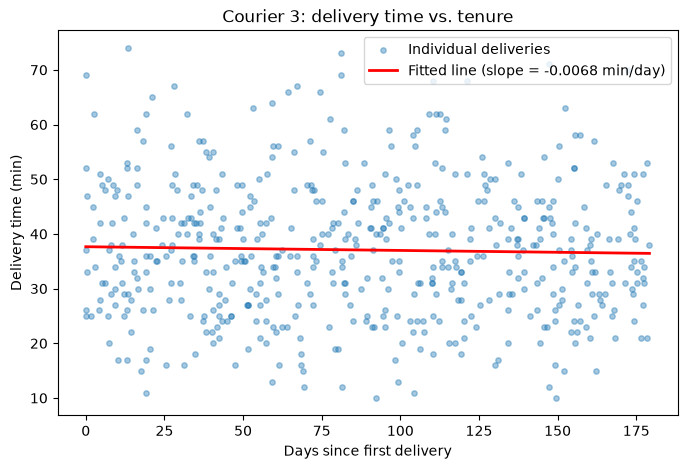

In [29]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(
    courier_3["days_since_first"], courier_3["delivery_time_min"],
    alpha=0.4, s=15, label="Individual deliveries",
)

x_line = np.array([courier_3["days_since_first"].min(), courier_3["days_since_first"].max()])
y_line = result.intercept + result.slope * x_line
ax.plot(x_line, y_line, color="red", linewidth=2, label=f"Fitted line (slope = {result.slope:.4f} min/day)")

ax.set_xlabel("Days since first delivery")
ax.set_ylabel("Delivery time (min)")
ax.set_title("Courier 3: delivery time vs. tenure")
ax.legend()
plt.show()

The fitted line is essentially flat, sitting in the middle of a wide, noisy scatter of points with no visible upward or downward drift — a visual match for the near-zero slope and the large p-value computed above.

### Deciding a minimum-deliveries threshold before generalizing

Before running this on every courier, it helps to see how many deliveries each one actually has — a regression fit on a handful of points can produce a "significant" slope purely by chance, since there is so little data to average the noise out.

In [30]:
deliveries_all.groupby("delivery_person_id").size().sort_values(ascending=False)

delivery_person_id
5     539
3     537
13    152
1     140
8     140
12    137
11    136
2     131
9     129
10    126
4     126
6     123
7     119
15      9
14      6
dtype: int64

Rather than picking a fixed number, the threshold is computed directly from this distribution: couriers are ranked by delivery volume, and the cutoff is set to the smallest delivery count found among the top 80% of couriers by volume. This way the rule adapts automatically to whatever the data looks like — a busier dataset with higher volumes per courier would produce a higher cutoff, a sparser one a lower cutoff — instead of hard-coding a number that only happens to make sense for this particular dataset.

In [31]:
counts_sorted = deliveries_all.groupby("delivery_person_id").size().sort_values(ascending=False)
n_couriers = len(counts_sorted)
top_n_couriers = int(np.ceil(0.8 * n_couriers))
MIN_DELIVERIES = counts_sorted.iloc[:top_n_couriers].min()

print(f"n_couriers: {n_couriers}")
print(f"keeping top {top_n_couriers} couriers (80%)")
print(f"MIN_DELIVERIES: {MIN_DELIVERIES}")

n_couriers: 15
keeping top 12 couriers (80%)
MIN_DELIVERIES: 123


With 15 couriers, the top 80% is the top 12, and the smallest delivery count within that group sets `MIN_DELIVERIES`. Worth flagging immediately: courier `7` sits just below this cutoff, by only a handful of deliveries. Whether that matters depends on what the regression finds below.

### Generalizing to every courier

`deliveries_all.groupby("delivery_person_id")` splits the deliveries into one sub-dataframe per courier. For each one with at least `MIN_DELIVERIES` rows, the same `add_days_since_first` + `linregress` steps used on courier `3` are repeated, and the slope, p-value, r-value, and delivery count are collected into a summary DataFrame — one row per courier.

In [32]:
trend_rows = []
for courier_id, courier_deliveries in deliveries_all.groupby("delivery_person_id"):
    if len(courier_deliveries) < MIN_DELIVERIES:
        continue
    courier_deliveries = add_days_since_first(courier_deliveries)
    result = stats.linregress(
        courier_deliveries["days_since_first"],
        courier_deliveries["delivery_time_min"],
    )
    trend_rows.append({
        "delivery_person_id": courier_id,
        "n_deliveries": len(courier_deliveries),
        "slope_min_per_day": result.slope,
        "pvalue": result.pvalue,
        "rvalue": result.rvalue,
    })

trend_df = pd.DataFrame(trend_rows).sort_values("slope_min_per_day", ascending=False)
trend_df

,delivery_person_id,n_deliveries,slope_min_per_day,pvalue,rvalue
9,6,123,0.018459,0.372921,0.081035
8,5,539,0.013181,0.209239,0.054171
5,2,131,0.006507,0.745079,0.028676
1,10,126,0.002542,0.906311,0.010590
3,12,137,-0.000650,0.972850,-0.002935
10,8,140,-0.004903,0.814723,-0.019982
6,3,537,-0.006782,0.510013,-0.028491
11,9,129,-0.013332,0.496167,-0.060451
0,1,140,-0.017658,0.391047,-0.073049
4,13,152,-0.025959,0.206686,-0.102999


12 couriers pass the volume filter, with slopes spread on both sides of zero. Turning this into a clear "increasing trend" verdict needs an explicit rule, defined here as: **`slope > 0` and `pvalue < 0.05`**. The `slope > 0` half is the direction (getting slower, not faster); the `pvalue < 0.05` half is the standard significance threshold used across most fields — it means there is less than a 5% chance of seeing a slope this positive if the courier's delivery time were not actually trending at all. 0.05 is a convention, not a law of nature, but it is a reasonable, widely understood bar for a first pass at this question, and it directly rules out the kind of false positive a low-volume courier could produce by chance (which `MIN_DELIVERIES` already reduces, and this p-value threshold guards against further).

In [33]:
ALPHA = 0.05

significant_increasing = trend_df[
    (trend_df["slope_min_per_day"] > 0) & (trend_df["pvalue"] < ALPHA)
]
significant_increasing

,delivery_person_id,n_deliveries,slope_min_per_day,pvalue,rvalue


With this data-driven threshold, the significant list comes back **empty** — no courier clears both the `slope > 0` and `pvalue < 0.05` bar. This is worth sitting with rather than glossing over: courier `7`, the one actually built with a real worsening trend, is excluded purely by the volume cutoff — not because its trend is not real, but because there was not quite enough data by this dataset's own definition of "enough."

This is a genuine finding about the method, not a bug in it: a dynamic threshold tied to the data's own distribution is more principled and reproducible than a hand-picked number, but it comes with a real trade-off — it can be conservative enough to filter out a borderline-but-genuine signal along with the noise it was designed to exclude. In a real deployment, this would be a reason to flag courier `7` for closer monitoring (a near-miss on the volume threshold, worth revisiting once more deliveries accumulate) rather than to conclude with confidence that no trend exists. This trade-off — and the fact that a fixed threshold used earlier as a first pass did flag courier `7` as significant — is exactly the kind of caveat worth carrying into `sql_insights.md`.